<a href="https://colab.research.google.com/github/Athirhama/RL/blob/Yani/mainv3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
import envv3 as env_module
import agentv3 as agent_module



In [4]:
def plot_convergence(sw_history, pol_history, window=50):
    # Calcul des moyennes mobiles pour lisser le "bruit" du RL
    sw_smoothed = np.convolve(sw_history, np.ones(window)/window, mode='valid')
    pol_smoothed = np.convolve(pol_history, np.ones(window)/window, mode='valid')

    plt.figure(figsize=(14, 5))

    # Plot Social Welfare
    plt.subplot(1, 2, 1)
    plt.plot(sw_history, alpha=0.3, color='blue', label='Brut')
    plt.plot(sw_smoothed, color='darkblue', linewidth=2, label=f'Moyenne ({window})')
    plt.title("Évolution du Social Welfare ($SW$)")
    plt.xlabel("Épisodes")
    plt.ylabel("Score SW")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot Pollution
    plt.subplot(1, 2, 2)
    plt.plot(pol_history, alpha=0.3, color='red', label='Brut')
    plt.plot(pol_smoothed, color='darkred', linewidth=2, label=f'Moyenne ({window})')
    plt.title("Stock de Pollution Final")
    plt.xlabel("Épisodes")
    plt.ylabel("Niveau de Pollution")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [5]:
def plot_firm_strategy(firm_agent, firm_name="Firme"):
    # On sépare les états de type Taxe (0)
    tax_states = sorted([s for s in firm_agent.q_table.keys() if s[0] == 0])

    if not tax_states:
        print("Pas assez de données dans la Q-table pour afficher la heatmap.")
        return

    # On construit la matrice : Lignes = Taxes, Colonnes = Quantités q
    q_matrix = np.array([firm_agent.q_table[s] for s in tax_states])
    tax_values = [s[1] for s in tax_states]
    q_values = np.round(firm_agent.actions, 1)

    plt.figure(figsize=(10, 6))
    sns.heatmap(q_matrix, annot=False, cmap="viridis",
                yticklabels=tax_values, xticklabels=q_values)
    plt.title(f"Cerveau de la {firm_name} (États de Taxe)")
    plt.ylabel("Valeur de la Taxe imposée par l'État")
    plt.xlabel("Quantité $q$ produite (Action choisie)")
    plt.show()

In [6]:
def plot_gov_decisions(gov_agent):
    # On récupère les états (pollution) connus par le gouvernement
    states = sorted(gov_agent.q_table.keys())
    best_actions = []

    for s in states:
        idx = np.argmax(gov_agent.q_table[s])
        a_type, a_val = gov_agent.actions[idx]
        best_actions.append((s * 5, a_type, a_val)) # s*5 pour revenir à la pollution réelle

    # On sépare pour le plot
    pollutions = [x[0] for x in best_actions]
    types = ["Taxe" if x[1] == 0 else "Quota" for x in best_actions]
    values = [x[2] for x in best_actions]

    plt.figure(figsize=(12, 5))

    # Scatter plot pour voir le type et la valeur
    colors = ['blue' if t == "Taxe" else 'orange' for t in types]
    plt.scatter(pollutions, values, c=colors, s=100, edgecolors='black', alpha=0.7)

    plt.title("Politique optimale choisie selon le niveau de Pollution")
    plt.xlabel("Niveau de Pollution")
    plt.ylabel("Valeur de la Politique (Taxe ou Quota)")
    plt.grid(True, linestyle='--', alpha=0.6)

    # Légende custom
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', label='Taxe', markerfacecolor='blue', markersize=10),
                       Line2D([0], [0], marker='o', color='w', label='Quota', markerfacecolor='orange', markersize=10)]
    plt.legend(handles=legend_elements)
    plt.show()

In [7]:
history_sw = []
history_pol = []

# --- Initialisation ---
env = env_module.EcoSystem()
gov = agent_module.GovernmentAgent()
firms = [agent_module.FirmAgent() for _ in range(env.n_firms)]

for ep in range(100000):
    state_vec = env.reset()
    pollution = state_vec[2]
    ep_sw = 0  # cumul du bien-être social

    for step in range(20):
        gov_idx = gov.get_action(pollution)
        a_type, a_val = gov.actions[gov_idx]

        q_indices, q_vals = [], []
        for f in firms:
            idx = f.get_action(a_type, a_val)
            q_indices.append(idx)
            q_vals.append(f.actions[idx])

        next_state_vec, reward_gov, rewards_firms = env.step_multi_firms(a_type, a_val, q_vals)
        next_pollution = next_state_vec[2]

        # Apprentissage
        for i in range(5):
            firms[i].learn(a_type, a_val, q_indices[i], rewards_firms[i])

        gov.learn(pollution, gov_idx, reward_gov, next_pollution)

        pollution = next_pollution
        ep_sw += reward_gov

    # --- FIN D'ÉPISODE ---
    history_sw.append(ep_sw)
    history_pol.append(pollution)

    gov.decay_epsilon() #decay à chaque épisode et non pas à chaque step
    for f in firms:
        f.decay_epsilon()

    if ep % 1000 == 0:
        print(f"Épisode {ep} terminé. Epsilon Gov: {gov.epsilon:.2f}")

Épisode 0 terminé. Epsilon Gov: 1.00
Épisode 1000 terminé. Epsilon Gov: 0.90
Épisode 2000 terminé. Epsilon Gov: 0.82
Épisode 3000 terminé. Epsilon Gov: 0.74
Épisode 4000 terminé. Epsilon Gov: 0.67
Épisode 5000 terminé. Epsilon Gov: 0.61
Épisode 6000 terminé. Epsilon Gov: 0.55
Épisode 7000 terminé. Epsilon Gov: 0.50
Épisode 8000 terminé. Epsilon Gov: 0.45
Épisode 9000 terminé. Epsilon Gov: 0.41
Épisode 10000 terminé. Epsilon Gov: 0.37
Épisode 11000 terminé. Epsilon Gov: 0.33
Épisode 12000 terminé. Epsilon Gov: 0.30
Épisode 13000 terminé. Epsilon Gov: 0.27
Épisode 14000 terminé. Epsilon Gov: 0.25
Épisode 15000 terminé. Epsilon Gov: 0.22
Épisode 16000 terminé. Epsilon Gov: 0.20
Épisode 17000 terminé. Epsilon Gov: 0.18
Épisode 18000 terminé. Epsilon Gov: 0.17
Épisode 19000 terminé. Epsilon Gov: 0.15
Épisode 20000 terminé. Epsilon Gov: 0.14
Épisode 21000 terminé. Epsilon Gov: 0.12
Épisode 22000 terminé. Epsilon Gov: 0.11
Épisode 23000 terminé. Epsilon Gov: 0.10
Épisode 24000 terminé. Epsilo

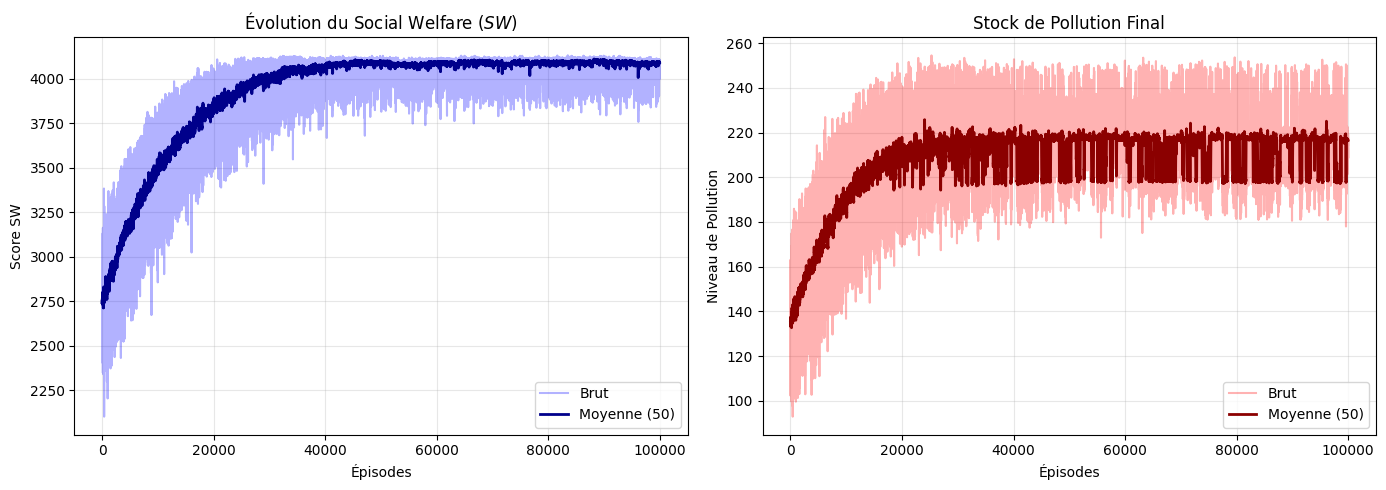

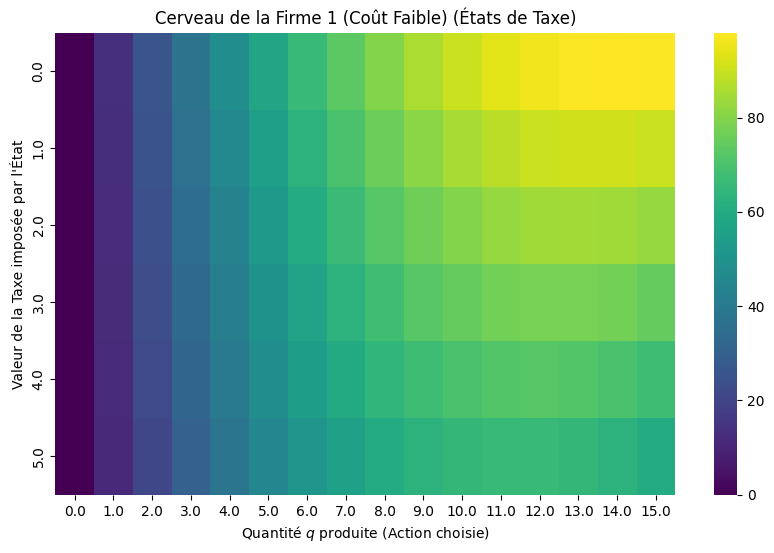

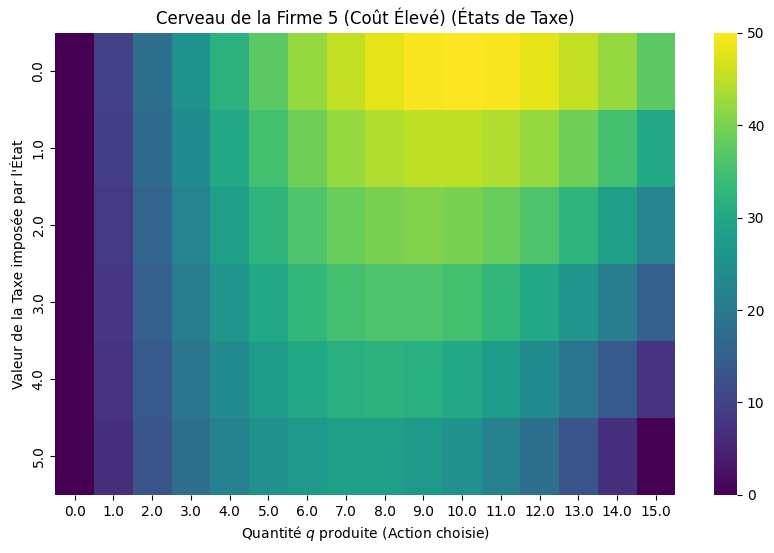

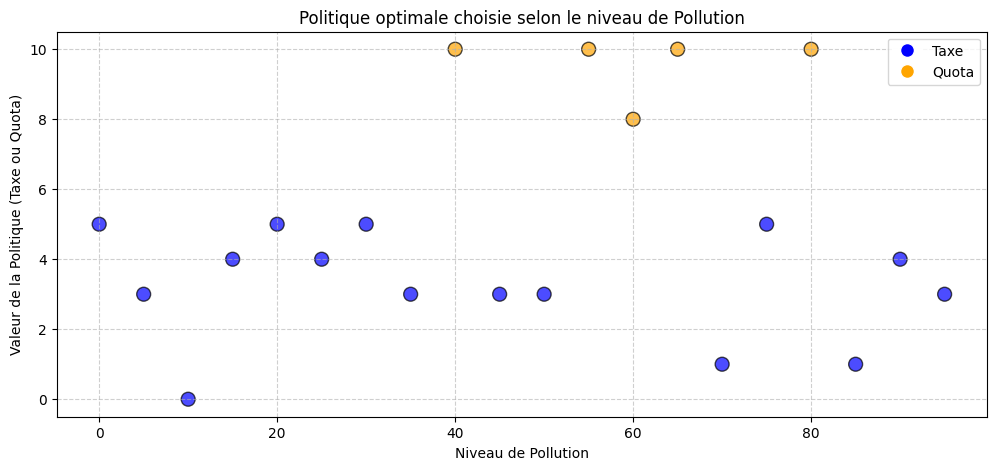

In [8]:
# 1. Voir si ça a convergé
plot_convergence(history_sw, history_pol)

# 2. Voir comment la Firme 1 (coût faible) et la Firme 5 (coût élevé) réagissent
plot_firm_strategy(firms[0], "Firme 1 (Coût Faible)")
plot_firm_strategy(firms[4], "Firme 5 (Coût Élevé)")

# 3. Voir ce que l'État a appris
plot_gov_decisions(gov)

In [9]:
def plot_policy_responses(firms_list):
    # Valeurs de politiques définies dans le Gouvernement
    tax_values = [0, 1, 2, 3, 4, 5]
    quota_values = [2, 4, 6, 8, 10]

    plt.figure(figsize=(15, 6))
    styles = ['-', '--', ':', '-.', (0, (3, 5, 1, 5))]

    # --- GRAPHIQUE 1 : RÉACTION À LA TAXE ---
    plt.subplot(1, 2, 1)
    for i, f in enumerate(firms_list):
        responses = []
        for v in tax_values:
            state_key = (0, float(v))
            if state_key in f.q_table:
                best_action_idx = np.argmax(f.q_table[state_key])
                responses.append(f.actions[best_action_idx])
            else:
                responses.append(None)

        plt.plot(tax_values, responses, marker='o', label=f"Firme {i+1} (a_i={1+i})")

    plt.title("Production apprise vs Niveau de Taxe")
    plt.xlabel("Valeur de la Taxe")
    plt.ylabel("Quantité produite $q$")
    plt.grid(True, alpha=0.3)
    plt.legend()

    # --- GRAPHIQUE 2 : RÉACTION AU QUOTA ---
    plt.subplot(1, 2, 2)
    for i, f in enumerate(firms_list):
        responses = []
        for v in quota_values:
            state_key = (1, float(v))
            if state_key in f.q_table:
                best_action_idx = np.argmax(f.q_table[state_key])
                responses.append(f.actions[best_action_idx])
            else:
                responses.append(None)

        plt.plot(quota_values, responses, marker='s', label=f"Firme {i+1}")

    plt.title("Production apprise vs Niveau de Quota")
    plt.xlabel("Valeur du Quota (Législatif)")
    plt.ylabel("Quantité produite $q$")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

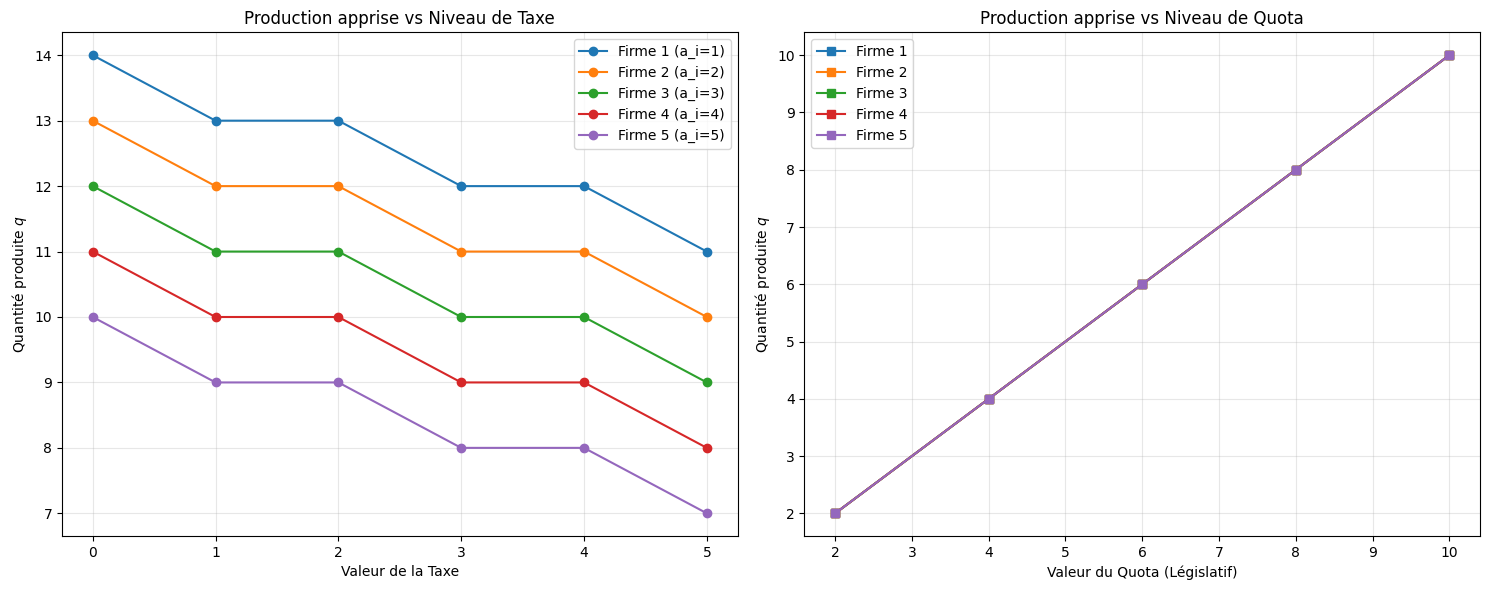

In [10]:
# Après l'entraînement :
plot_policy_responses(firms)

### Expected Sarsa


In [12]:
#Initialization for expected Sarsa
history_sw_sarsa = []
history_pol_sarsa = []

env_sarsa = env_module.EcoSystem()
gov_sarsa = agent_module.GovernmentAgent()
firms_sarsa = [agent_module.FirmAgent() for _ in range(env_sarsa.n_firms)]



In [13]:
# Training loop : expected Sarsa
n_episodes = 100000

for ep in range(n_episodes):
    state_vec = env_sarsa.reset()
    pollution = state_vec[2]
    ep_sw = 0

    for step in range(20):
        # Government chooses action
        gov_idx = gov_sarsa.get_action(pollution)
        a_type, a_val = gov_sarsa.actions[gov_idx]

        # Firms choose production quantities
        q_indices, q_vals = [], []
        for f in firms_sarsa:
            idx = f.get_action(a_type, a_val)
            q_indices.append(idx)
            q_vals.append(f.actions[idx])

        # Environment step
        next_state_vec, reward_gov, rewards_firms = env_sarsa.step_multi_firms(a_type, a_val, q_vals)
        next_pollution = next_state_vec[2]

        # Firms learn (standard update)
        for i in range(env_sarsa.n_firms):
            firms_sarsa[i].learn(a_type, a_val, q_indices[i], rewards_firms[i])

        # GOVERNMENT LEARNS WITH EXPECTED SARSA
        gov_sarsa.learn_expected_sarsa(pollution, gov_idx, reward_gov, next_pollution)

        pollution = next_pollution
        ep_sw += reward_gov

    # End of episode updates
    history_sw_sarsa.append(ep_sw)
    history_pol_sarsa.append(pollution)

    gov_sarsa.decay_epsilon()
    for f in firms_sarsa:
        f.decay_epsilon()

    if ep % 5000 == 0:
        print(f"Épisode {ep} (SARSA) terminé. Epsilon: {gov_sarsa.epsilon:.2f}")

print("Entraînement SARSA terminé.")

Épisode 0 (SARSA) terminé. Epsilon: 1.00
Épisode 5000 (SARSA) terminé. Epsilon: 0.61
Épisode 10000 (SARSA) terminé. Epsilon: 0.37
Épisode 15000 (SARSA) terminé. Epsilon: 0.22
Épisode 20000 (SARSA) terminé. Epsilon: 0.14
Épisode 25000 (SARSA) terminé. Epsilon: 0.08
Épisode 30000 (SARSA) terminé. Epsilon: 0.05
Épisode 35000 (SARSA) terminé. Epsilon: 0.03
Épisode 40000 (SARSA) terminé. Epsilon: 0.02
Épisode 45000 (SARSA) terminé. Epsilon: 0.01
Épisode 50000 (SARSA) terminé. Epsilon: 0.01
Épisode 55000 (SARSA) terminé. Epsilon: 0.01
Épisode 60000 (SARSA) terminé. Epsilon: 0.01
Épisode 65000 (SARSA) terminé. Epsilon: 0.01
Épisode 70000 (SARSA) terminé. Epsilon: 0.01
Épisode 75000 (SARSA) terminé. Epsilon: 0.01
Épisode 80000 (SARSA) terminé. Epsilon: 0.01
Épisode 85000 (SARSA) terminé. Epsilon: 0.01
Épisode 90000 (SARSA) terminé. Epsilon: 0.01
Épisode 95000 (SARSA) terminé. Epsilon: 0.01
Entraînement SARSA terminé.


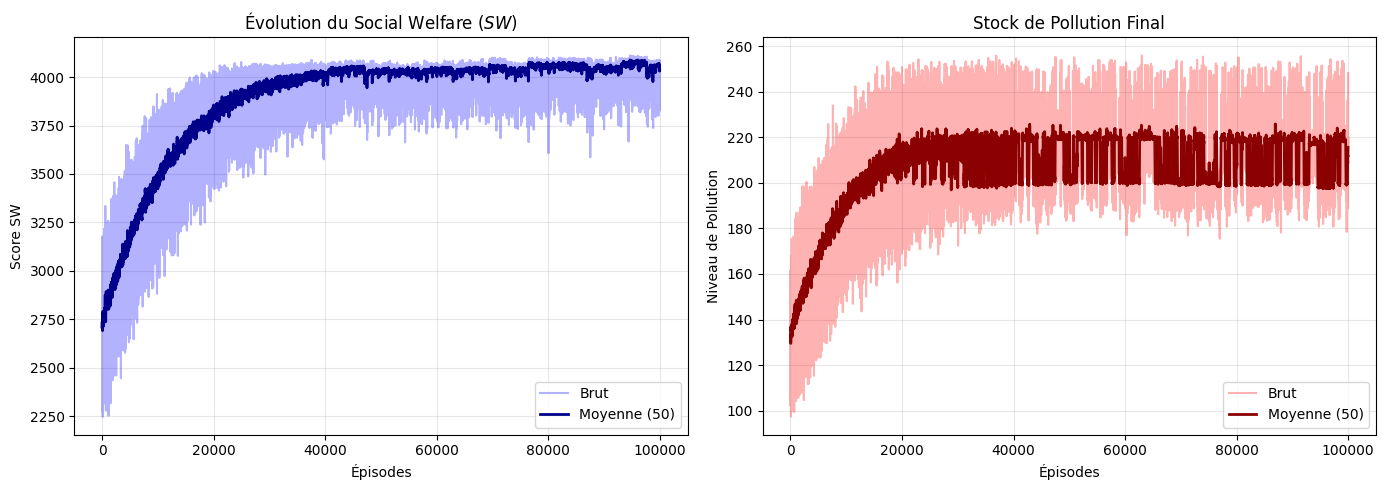

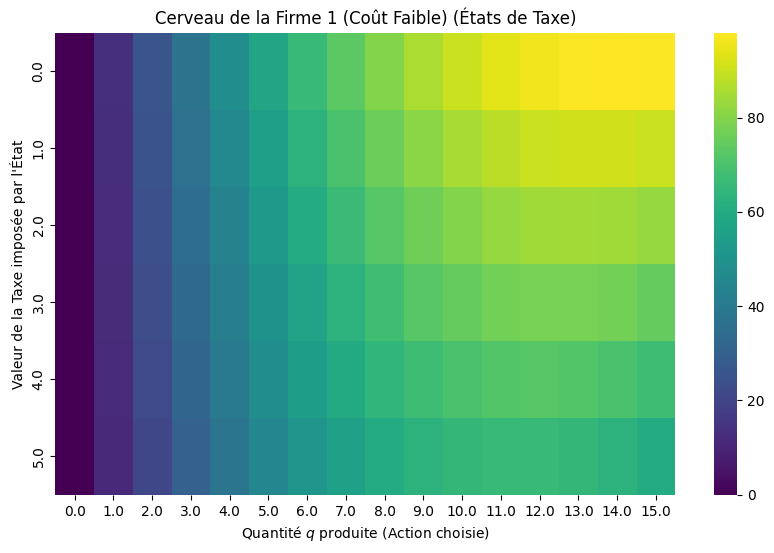

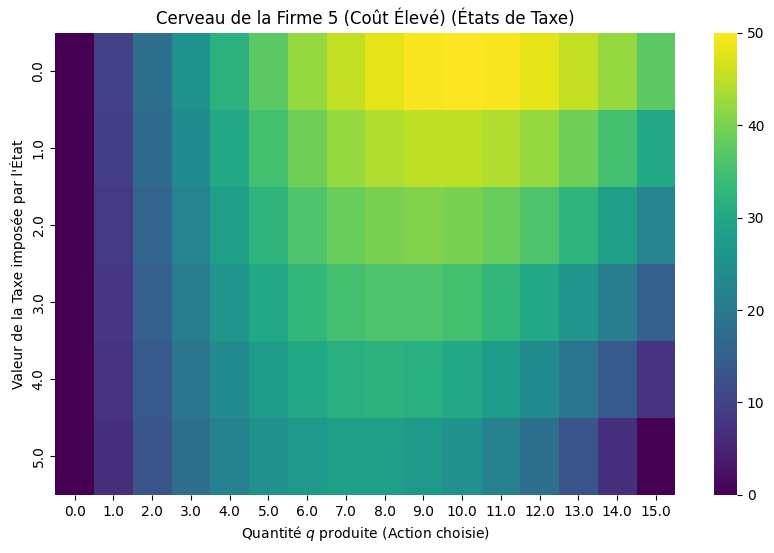

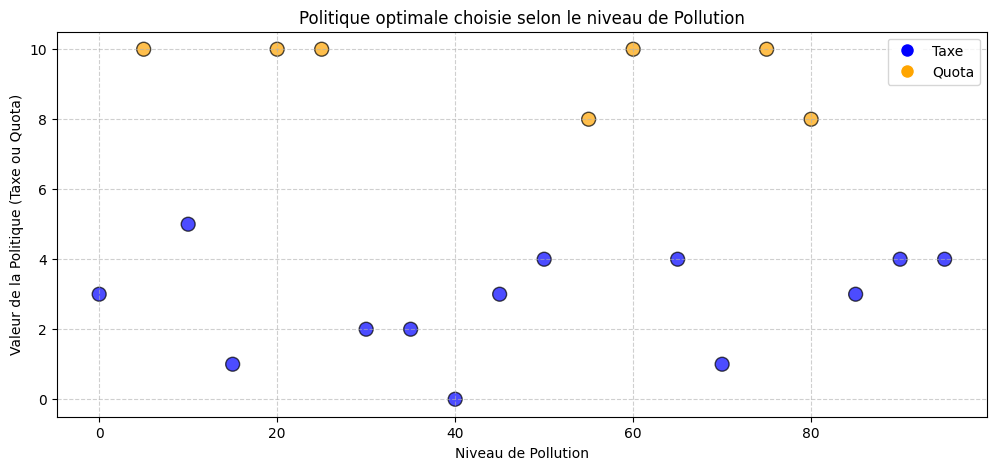

In [14]:
# 1. Voir si ça a convergé
plot_convergence(history_sw_sarsa, history_pol_sarsa)

# 2. Voir comment la Firme 1 (coût faible) et la Firme 5 (coût élevé) réagissent
plot_firm_strategy(firms_sarsa[0], "Firme 1 (Coût Faible)")
plot_firm_strategy(firms_sarsa[4], "Firme 5 (Coût Élevé)")

# 3. Voir ce que l'État a appris
plot_gov_decisions(gov_sarsa)

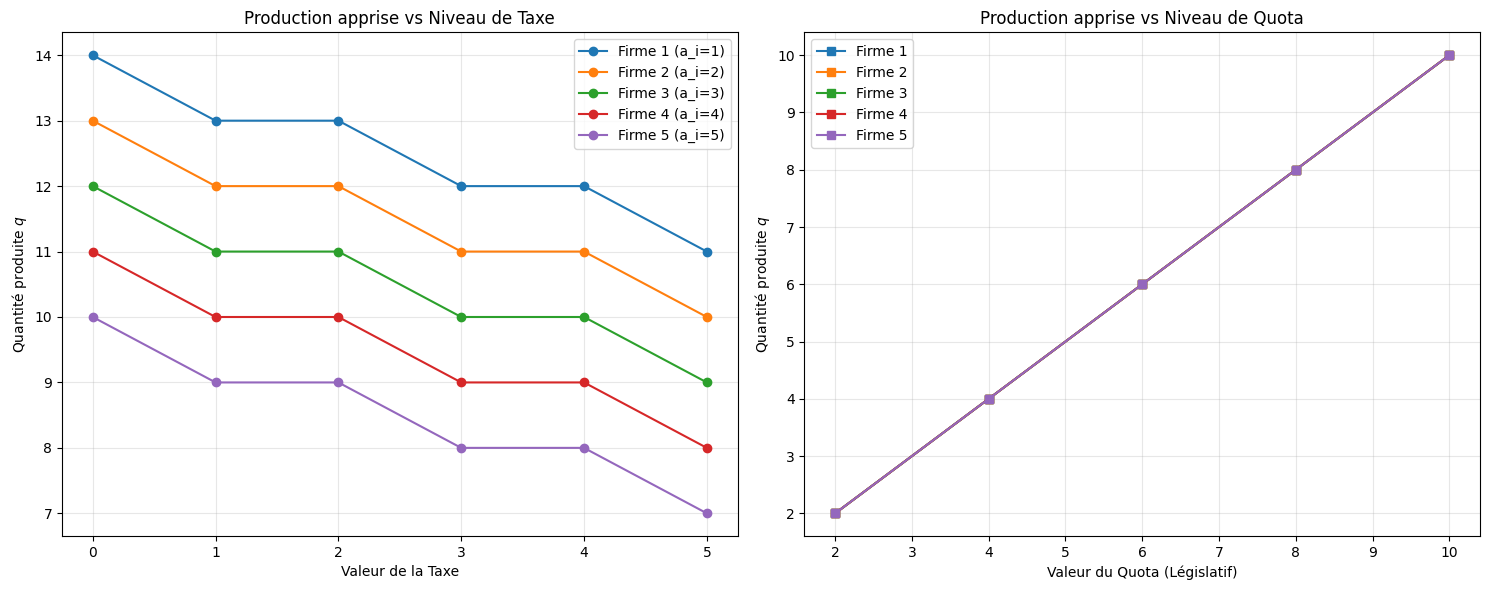

In [15]:
plot_policy_responses(firms_sarsa)

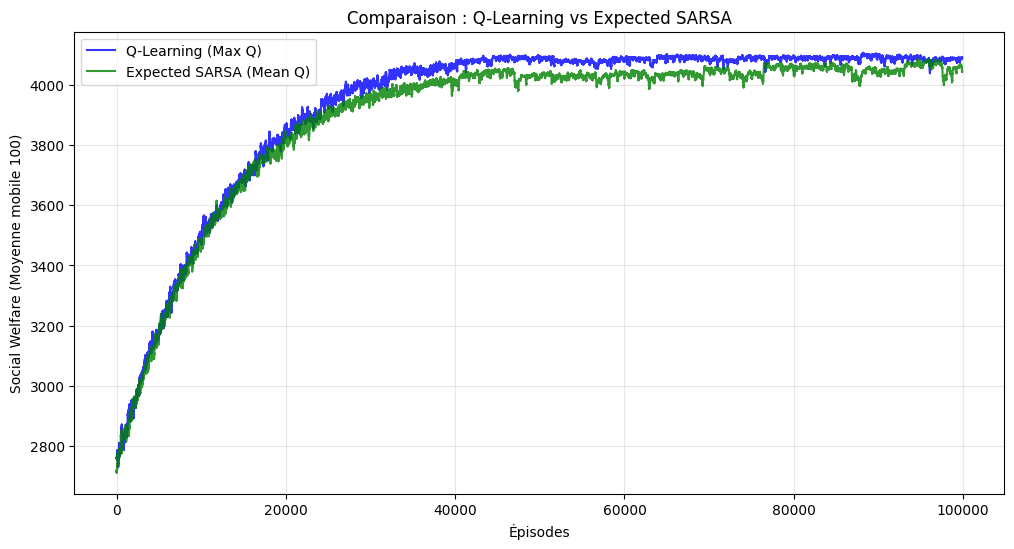

In [16]:
def plot_comparison(history_q, history_sarsa, window=100):
    # Lissage des deux courbes
    q_smoothed = np.convolve(history_q, np.ones(window)/window, mode='valid')
    sarsa_smoothed = np.convolve(history_sarsa, np.ones(window)/window, mode='valid')

    plt.figure(figsize=(12, 6))
    plt.plot(q_smoothed, label="Q-Learning (Max Q)", color='blue', alpha=0.8)
    plt.plot(sarsa_smoothed, label="Expected SARSA (Mean Q)", color='green', alpha=0.8)

    plt.title("Comparaison : Q-Learning vs Expected SARSA")
    plt.xlabel("Épisodes")
    plt.ylabel(f"Social Welfare (Moyenne mobile {window})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Assurez-vous que history_sw (de votre premier run) existe encore
plot_comparison(history_sw, history_sw_sarsa)

### Expériences sur les paramètres

In [26]:
def run_ablation(param_name, values, n_episodes=40000):
    results = {}

    for val in values:
        print(f"--- Testing {param_name} = {val} ---")
        env = env_module.EcoSystem()
        # Dynamically update the specific parameter
        setattr(env, param_name, val)

        gov = agent_module.GovernmentAgent()
        firms = [agent_module.FirmAgent() for _ in range(env.n_firms)]

        # Training loop
        for ep in range(n_episodes):
            state = env.reset()
            pollution = state[2]
            for step in range(20):
                g_idx = gov.get_action(pollution)
                a_type, a_val = gov.actions[g_idx]

                # Simple list comprehension for firm actions
                q_vals = [f.actions[f.get_action(a_type, a_val)] for f in firms]

                next_state, r_gov, r_firms = env.step_multi_firms(a_type, a_val, q_vals)

                # Learn
                gov.learn_expected_sarsa(pollution, g_idx, r_gov, env.pollution)
                for i in range(len(firms)):
                    firms[i].learn(a_type, a_val, 0, r_firms[i]) # Simplified for ablation speed

                pollution = env.pollution

            gov.decay_epsilon()
            for f in firms: f.decay_epsilon()

        results[val] = gov
    return results

def plot_policy_shift(results_dict, title_prefix):
    plt.figure(figsize=(16, 10))
    for i, (val, gov_agent) in enumerate(results_dict.items()):
        plt.subplot(2, 2, i+1)
        states = sorted(gov_agent.q_table.keys())
        pollutions = [s * 5 for s in states]

        types, values = [], []
        for s in states:
            best_idx = np.argmax(gov_agent.q_table[s])
            a_type, a_val = gov_agent.actions[best_idx]
            types.append("Tax" if a_type == 0 else "Quota")
            values.append(a_val)

        colors = ['blue' if t == "Tax" else 'orange' for t in types]
        plt.scatter(pollutions, values, c=colors, s=80, edgecolors='black', alpha=0.7)
        plt.title(f"{title_prefix} = {val}")
        plt.xlabel("Pollution")
        plt.ylabel("Policy Value")
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3242/2133958086.py:6: SyntaxWarning: invalid escape sequence '\l'
  plot_policy_shift(results_lambda, "Damage Coeff ($\lambda$)")


--- Testing lambda_env = 0.1 ---
--- Testing lambda_env = 1.0 ---
--- Testing lambda_env = 5.0 ---
--- Testing lambda_env = 10.0 ---


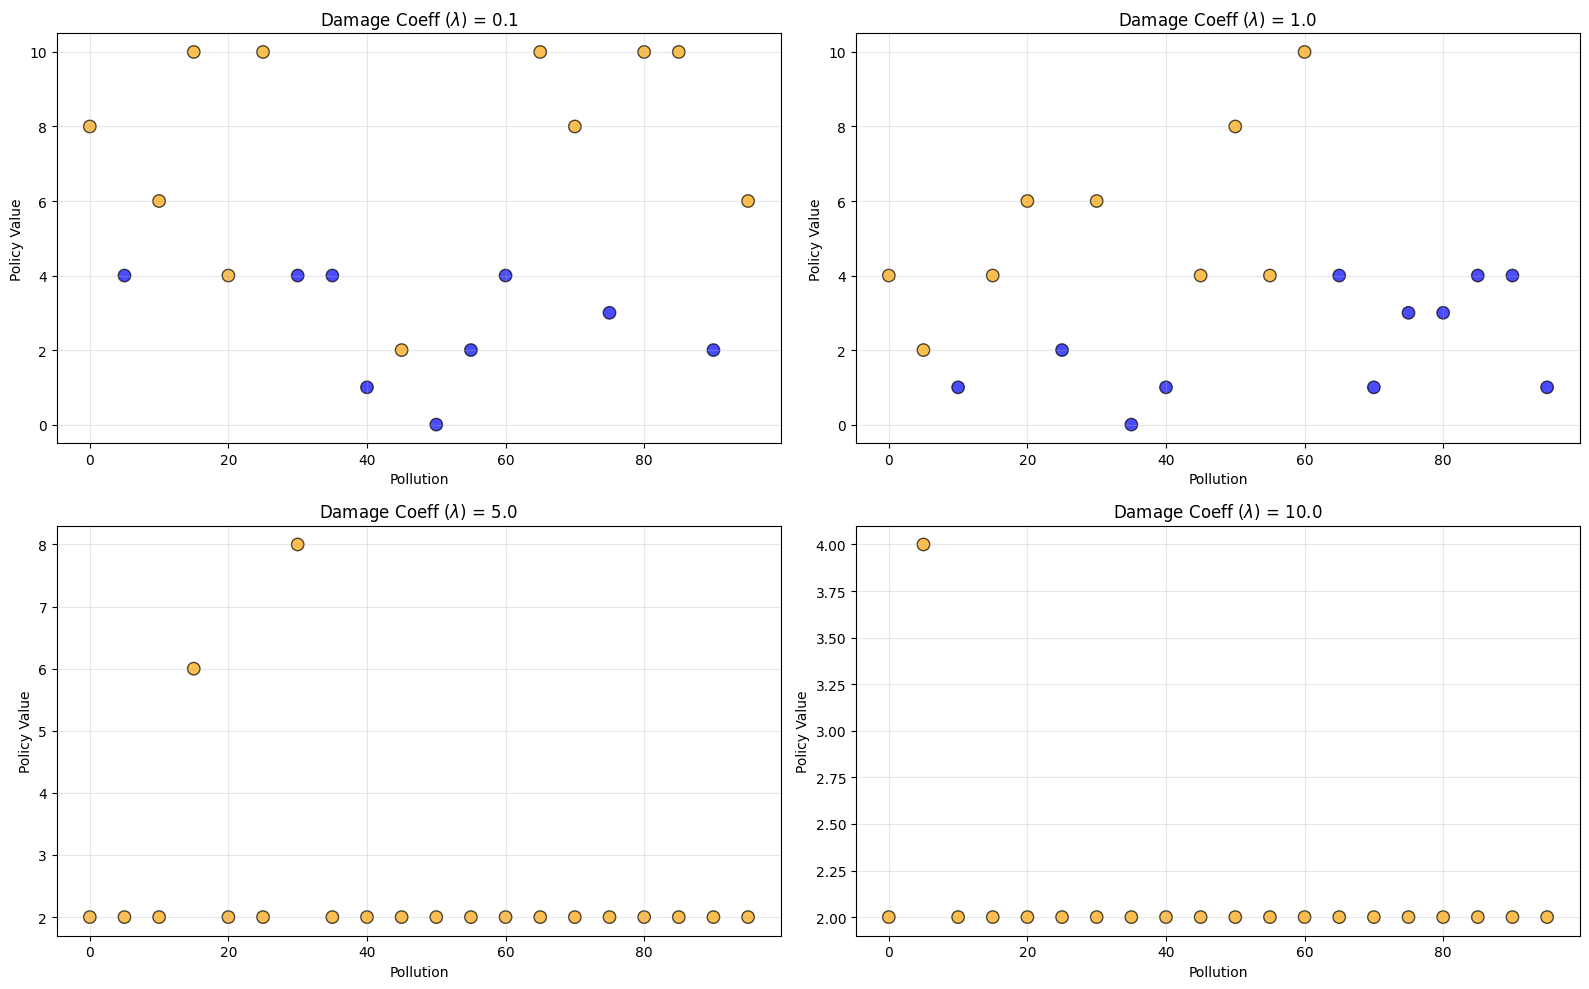

In [27]:
# 1. Run experiment
lambda_vals = [0.1, 1.0, 5.0, 10.0]
results_lambda = run_ablation('lambda_env', lambda_vals)

# 2. Plot
plot_policy_shift(results_lambda, "Damage Coeff ($\lambda$)")

--- Testing rho = 0.1 ---
--- Testing rho = 0.5 ---
--- Testing rho = 0.8 ---
--- Testing rho = 0.95 ---


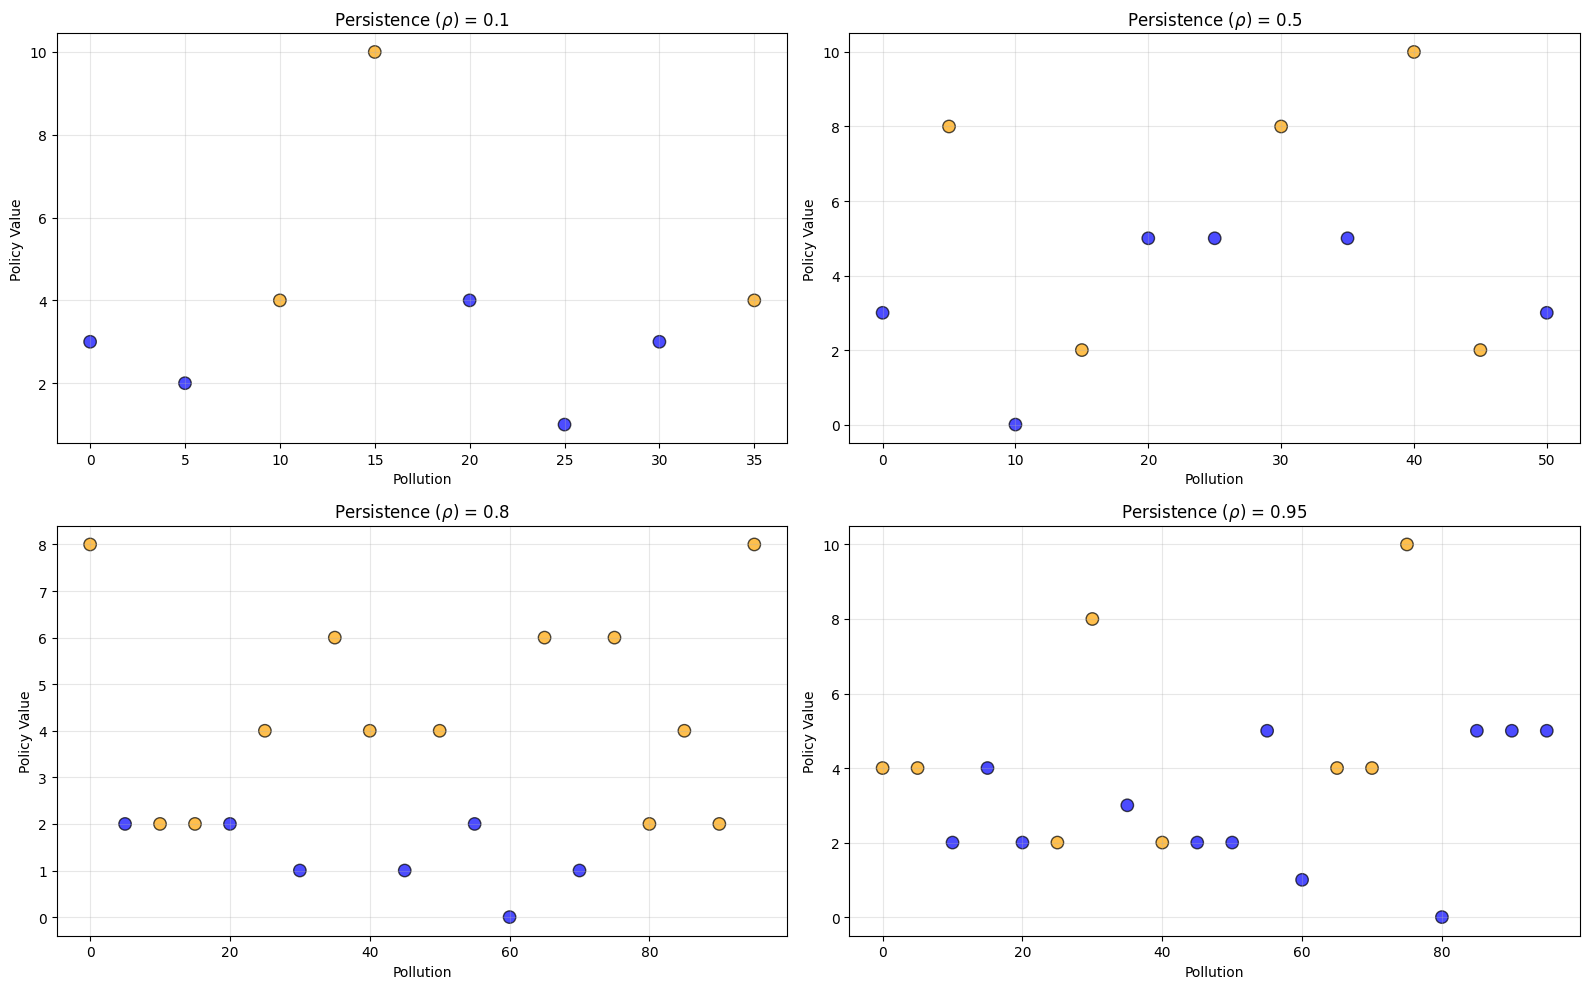

In [28]:
# 1. Run experiment
rho_vals = [0.1, 0.5, 0.8, 0.95]
results_rho = run_ablation('rho', rho_vals)

# 2. Plot
plot_policy_shift(results_rho, "Persistence ($\\rho$)")

--- Testing p = 10.0 ---
--- Testing p = 15.0 ---
--- Testing p = 20.0 ---
--- Testing p = 30.0 ---


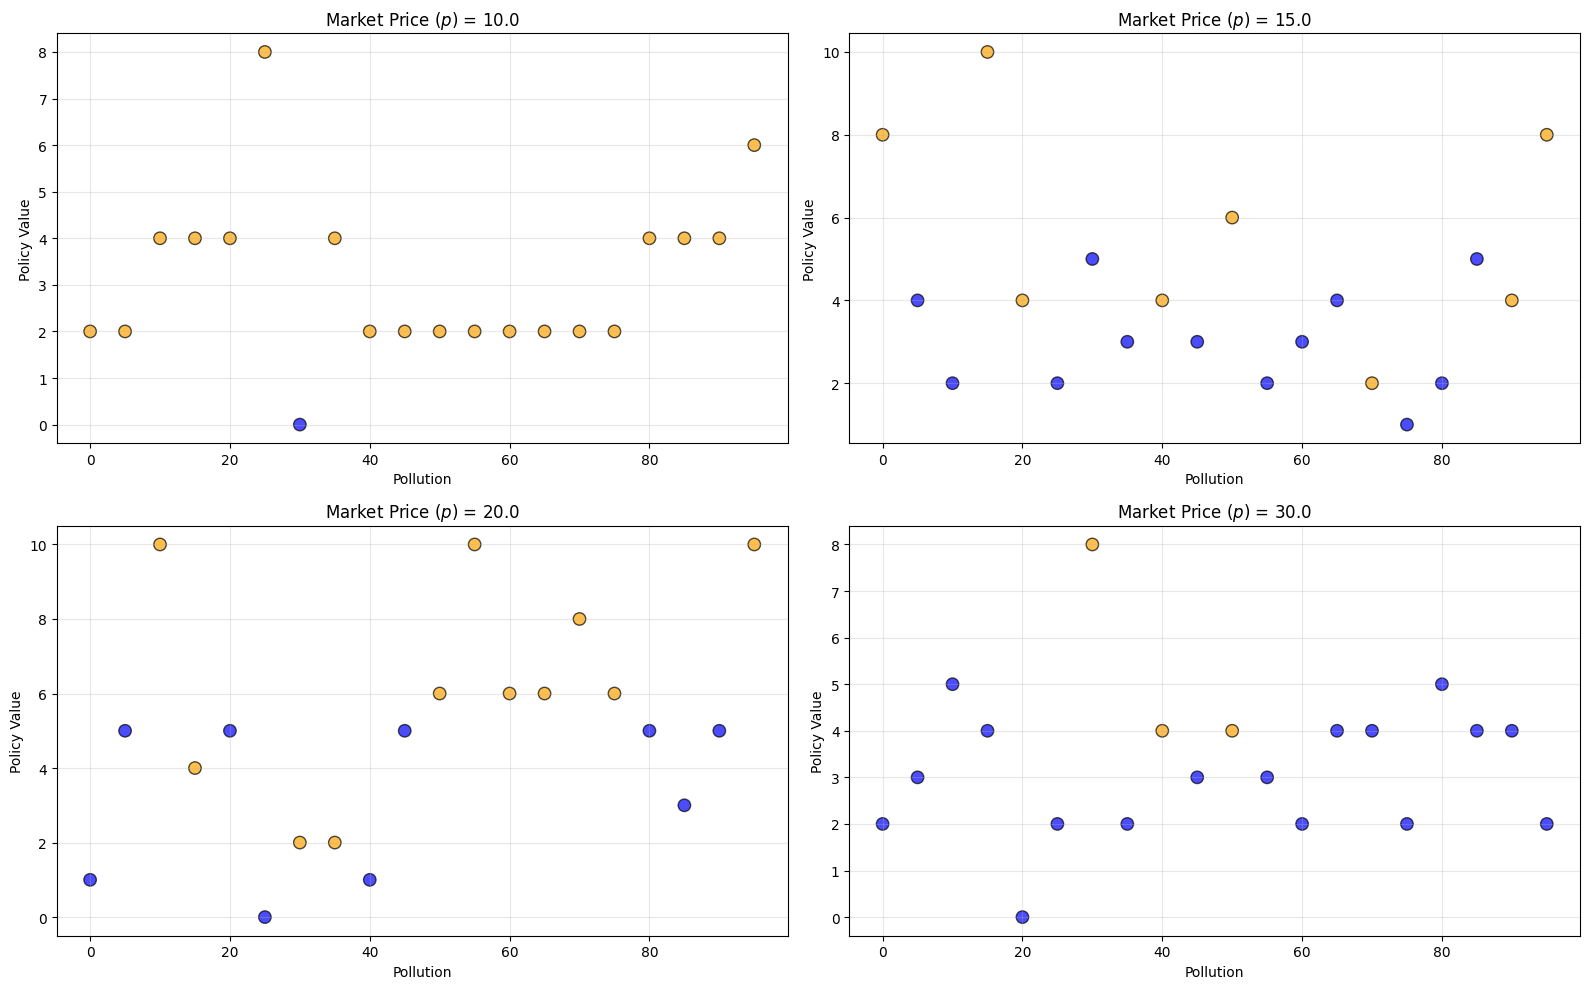

In [29]:
# 1. Run experiment
price_vals = [10.0, 15.0, 20.0, 30.0]
results_price = run_ablation('p', price_vals)

# 2. Plot
plot_policy_shift(results_price, "Market Price ($p$)")

1. Impact of Damage Coefficient (λ)

This experiment represents the "Social Priority".

  - Low Damage (λ=0.1 and 1.0): The agent is "undecided" and experimental. We see a mix of taxes and high quotas. Because pollution isn't very costly, the agent allows high production (Policy Values up to 10) because the gain in firm profits outweighs the small environmental penalty.

  - High Damage (λ=5.0 and 10.0): There is a dramatic shift. The agent completely abandons high-value policies. It settles almost exclusively on strict Quotas (Orange) fixed at a low value (Value = 2).

   - So When pollution becomes a major threat to Social Welfare, the agent switches from "Price Control" (Tax) to "Quantity Control" (Quota) because quotas provide a hard ceiling on damage that taxes cannot guarantee as easily.

2. Impact of Persistence (ρ)

This represents the "Memory" of the ecosystem.

  - Low Persistence (ρ=0.1): The agent is quite relaxed. Since pollution disappears almost immediately, it can afford to be lenient. You see a variety of policies, including Taxes.

   - High Persistence (ρ=0.95): This is the "Climate Change" scenario. Since pollution stays for a long time, every unit produced today penalizes the Social Welfare for dozens of steps.

   - Key Insight: In the ρ=0.95 plot, the agent uses more Taxes (Blue) at higher pollution levels. This acts as a "corrective" measure: it doesn't just stop production, it tries to extract value (Tax Revenue) to offset the long-term damage that it knows it cannot get rid of easily.

3. Impact of Market Price (p)


  - Low Price (p=10): The agent uses low quotas and low taxes. Since production isn't very profitable anyway, the firms don't have a strong incentive to over-pollute, so the government doesn't need to be overly aggressive.

  - High Price (p=30): Many more Blue dots (Taxes) appear.

  - Key Insight: When the market price is high (p=30), firms are desperate to produce. A Quota might be too restrictive for the economy. Instead, the Government learns to use Taxes.  It balances high firm profits with high tax revenue for the state.